# Project Milestone 1

In [1]:
import sqlite3
import pandas as pd

# Loaded raw CSV
df = pd.read_csv('team_traditional.csv')

# Create a SQLite database file and connect to it
conn = sqlite3.connect('capstone.db')

# Write the dataframe into a table in that database
df.to_sql('team_traditional', conn, if_exists='replace', index=False)

73404

In [2]:
query = "SELECT * FROM team_traditional WHERE season = 2025 AND type = 'regular'"
df_2025 = pd.read_sql(query, conn)

print(len(df_2025))
df_2025.head()

2460


,gameid,date,type,teamid,team,home,away,MIN,PTS,FGM,...,DREB,REB,AST,TOV,STL,BLK,PF,+/-,win,season
0,22400061,2024-10-22,regular,1610612738,BOS,BOS,NYK,48.0,132.0,48.0,...,29.0,40.0,33.0,4.0,6.0,3.0,15.0,23.0,1.0,2025
1,22400061,2024-10-22,regular,1610612752,NYK,BOS,NYK,48.0,109.0,43.0,...,29.0,34.0,20.0,12.0,2.0,3.0,12.0,-23.0,0.0,2025
2,22400062,2024-10-22,regular,1610612747,LAL,LAL,MIN,48.0,110.0,42.0,...,31.0,46.0,22.0,7.0,7.0,8.0,22.0,7.0,1.0,2025
3,22400062,2024-10-22,regular,1610612750,MIN,LAL,MIN,48.0,103.0,35.0,...,35.0,47.0,17.0,16.0,4.0,1.0,22.0,-7.0,0.0,2025
4,22400063,2024-10-23,regular,1610612754,IND,DET,IND,48.0,115.0,42.0,...,32.0,39.0,32.0,15.0,10.0,8.0,23.0,6.0,1.0,2025


In [3]:
# Check missing values for every column
df_2025.isnull().sum()

,0
gameid,0
date,0
type,0
teamid,0
team,0
home,0
away,0
MIN,0
PTS,0
FGM,0


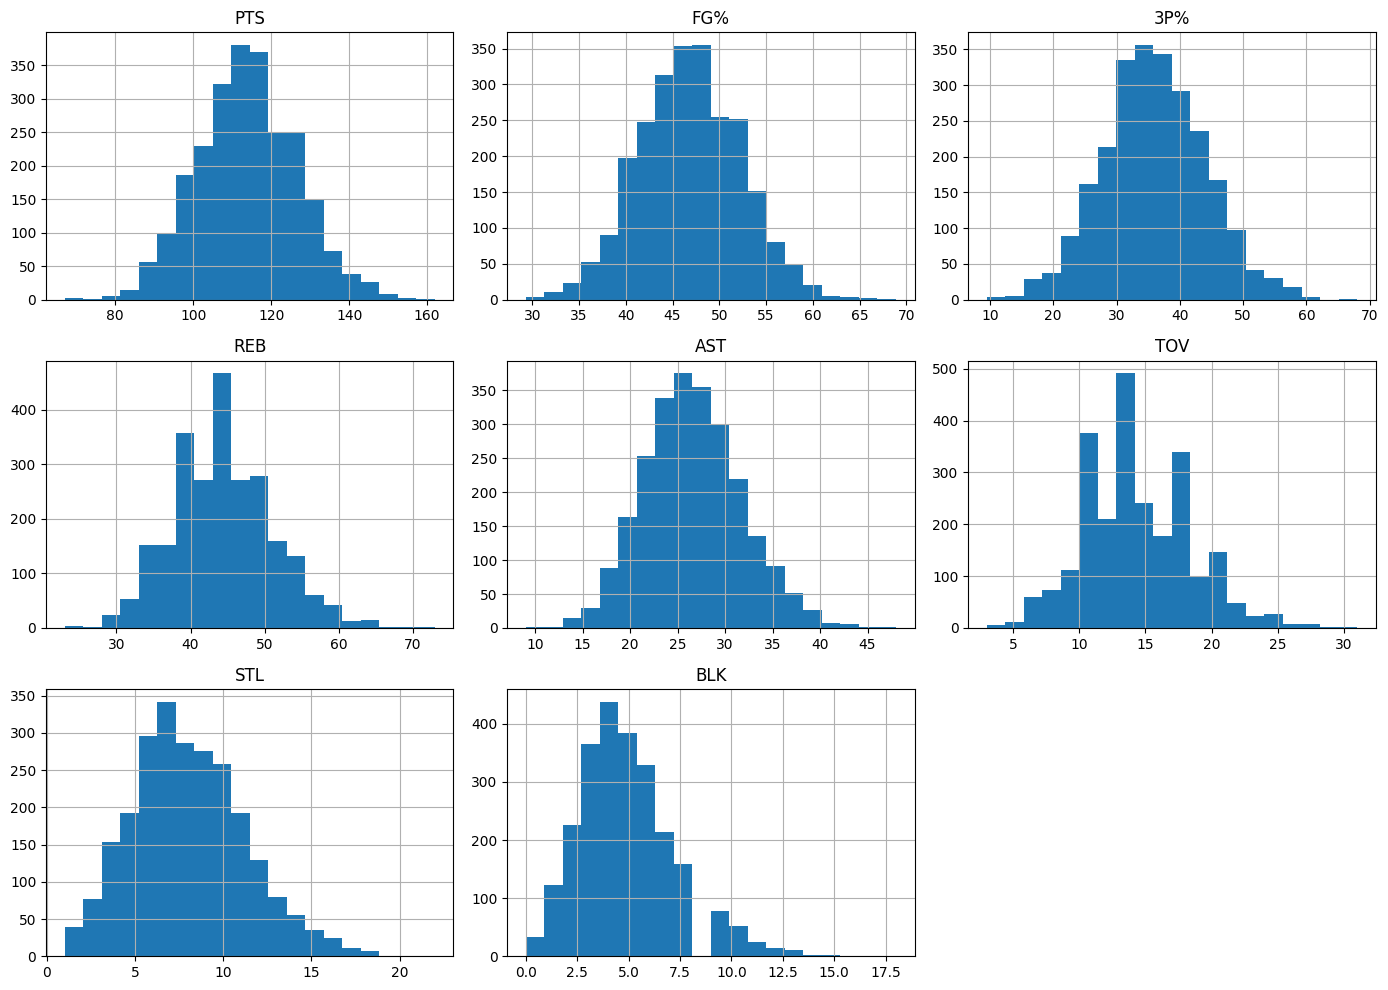

In [4]:

import matplotlib.pyplot as plt

stats = ['PTS', 'FG%', '3P%', 'REB', 'AST', 'TOV', 'STL', 'BLK']

df_2025[stats].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

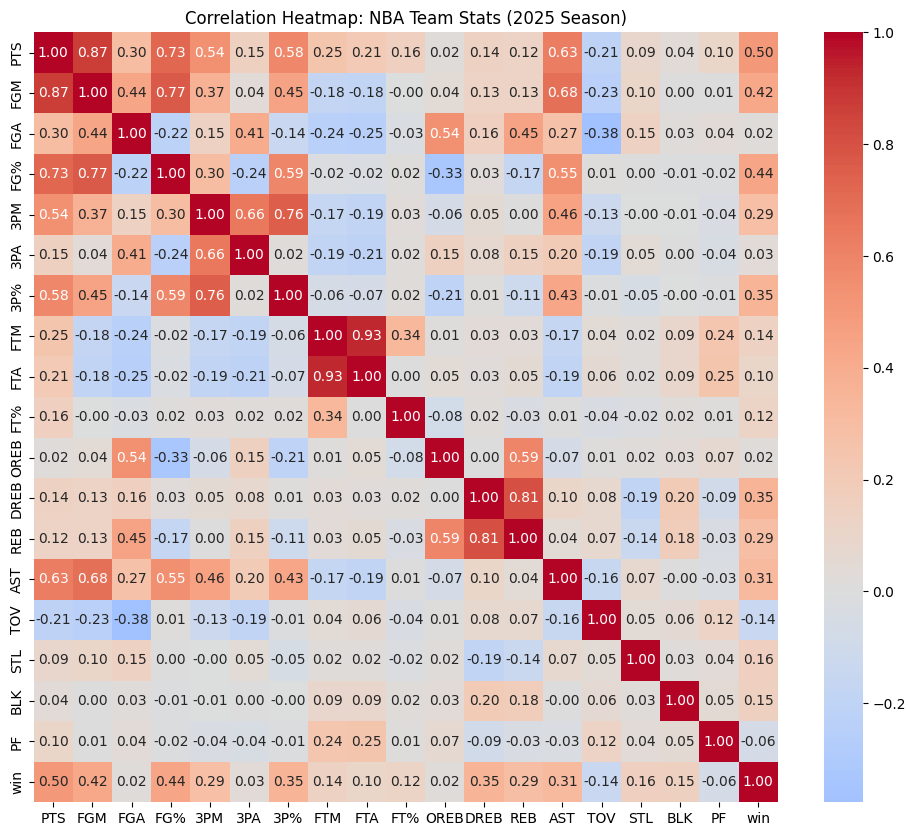

In [5]:
import seaborn as sns

statistics = ['PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%',
                 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'win']

plt.figure(figsize=(12, 10))
sns.heatmap(df_2025[statistics].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: NBA Team Stats (2025 Season)')
plt.show()

# Project Milestone 2

In [6]:
df_2025.head(10)

,gameid,date,type,teamid,team,home,away,MIN,PTS,FGM,...,DREB,REB,AST,TOV,STL,BLK,PF,+/-,win,season
0,22400061,2024-10-22,regular,1610612738,BOS,BOS,NYK,48.0,132.0,48.0,...,29.0,40.0,33.0,4.0,6.0,3.0,15.0,23.0,1.0,2025
1,22400061,2024-10-22,regular,1610612752,NYK,BOS,NYK,48.0,109.0,43.0,...,29.0,34.0,20.0,12.0,2.0,3.0,12.0,-23.0,0.0,2025
2,22400062,2024-10-22,regular,1610612747,LAL,LAL,MIN,48.0,110.0,42.0,...,31.0,46.0,22.0,7.0,7.0,8.0,22.0,7.0,1.0,2025
3,22400062,2024-10-22,regular,1610612750,MIN,LAL,MIN,48.0,103.0,35.0,...,35.0,47.0,17.0,16.0,4.0,1.0,22.0,-7.0,0.0,2025
4,22400063,2024-10-23,regular,1610612754,IND,DET,IND,48.0,115.0,42.0,...,32.0,39.0,32.0,15.0,10.0,8.0,23.0,6.0,1.0,2025
5,22400063,2024-10-23,regular,1610612765,DET,DET,IND,48.0,109.0,38.0,...,26.0,38.0,22.0,14.0,6.0,2.0,21.0,-6.0,0.0,2025
6,22400064,2024-10-23,regular,1610612737,ATL,ATL,BKN,48.0,120.0,39.0,...,33.0,45.0,25.0,16.0,12.0,9.0,20.0,4.0,1.0,2025
7,22400064,2024-10-23,regular,1610612751,BKN,ATL,BKN,48.0,116.0,40.0,...,31.0,43.0,21.0,19.0,8.0,6.0,32.0,-4.0,0.0,2025
8,22400065,2024-10-23,regular,1610612753,ORL,MIA,ORL,48.0,116.0,41.0,...,39.0,57.0,28.0,14.0,8.0,8.0,21.0,19.0,1.0,2025
9,22400065,2024-10-23,regular,1610612748,MIA,MIA,ORL,48.0,97.0,32.0,...,32.0,41.0,24.0,11.0,5.0,8.0,19.0,-19.0,0.0,2025


In [7]:
# Check missing values for every column
df_2025.isnull().sum()

,0
gameid,0
date,0
type,0
teamid,0
team,0
home,0
away,0
MIN,0
PTS,0
FGM,0


In [8]:
# Check missing values as a percentage per column
print((df_2025.isnull().sum() / len(df_2025)) * 100)

gameid    0.0
date      0.0
type      0.0
teamid    0.0
team      0.0
home      0.0
away      0.0
MIN       0.0
PTS       0.0
FGM       0.0
FGA       0.0
FG%       0.0
3PM       0.0
3PA       0.0
3P%       0.0
FTM       0.0
FTA       0.0
FT%       0.0
OREB      0.0
DREB      0.0
REB       0.0
AST       0.0
TOV       0.0
STL       0.0
BLK       0.0
PF        0.0
+/-       0.0
win       0.0
season    0.0
dtype: float64


win
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


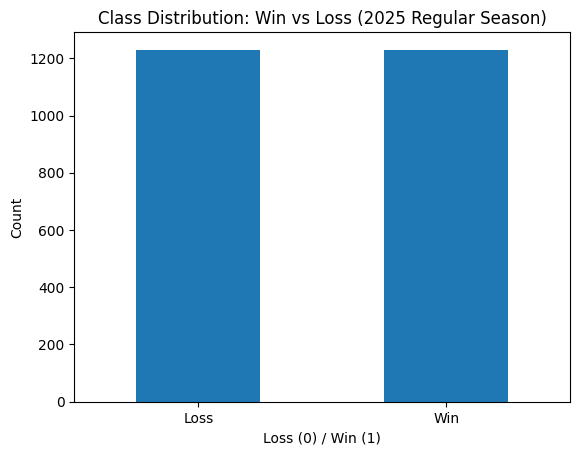

In [9]:
# Part 2: check data imbalance

# Check class distribution of the target variable
print(df_2025['win'].value_counts(normalize=True))

# Bar chart of class distribution
import matplotlib.pyplot as plt

df_2025['win'].value_counts().sort_index().plot(kind='bar')
plt.title('Class Distribution: Win vs Loss (2025 Regular Season)')
plt.xlabel('Loss (0) / Win (1)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Loss', 'Win'], rotation=0)
plt.show()

In [10]:
#part 3:feature engineering

# Convert date to datetime and sort chronologically per team
df_2025['date'] = pd.to_datetime(df_2025['date'])
df_2025 = df_2025.sort_values(['team', 'date']).reset_index(drop=True)

In [11]:
# New features: opponent, home/away, assist to turnover ratio, rest days
df_2025['opponent'] = df_2025.apply(lambda r: r['away'] if r['team']==r['home'] else r['home'], axis=1)
df_2025['is_home'] = (df_2025['team'] == df_2025['home']).astype(int)
df_2025['ast_tov_ratio'] = df_2025['AST'] / df_2025['TOV'].replace(0, 1)
df_2025['rest_days'] = df_2025.groupby('team')['date'].diff().dt.days

In [12]:
# Rolling averages (5-game and 10-game)
stats = ['PTS', 'FG%', '3P%', 'REB', 'AST', 'TOV', 'STL', 'BLK']

for s in stats:
    shifted = df_2025.groupby('team')[s].shift(1)
    df_2025[f'{s}_roll5'] = shifted.groupby(df_2025['team']).rolling(5, min_periods=2).mean().reset_index(drop=True)
    df_2025[f'{s}_roll10'] = shifted.groupby(df_2025['team']).rolling(10, min_periods=2).mean().reset_index(drop=True)

In [13]:
# Rolling AST/TOV ratio
shifted_ratio = df_2025.groupby('team')['ast_tov_ratio'].shift(1)
df_2025['ast_tov_roll5'] = shifted_ratio.groupby(df_2025['team']).rolling(5, min_periods=2).mean().reset_index(drop=True)
df_2025['ast_tov_roll10'] = shifted_ratio.groupby(df_2025['team']).rolling(10, min_periods=2).mean().reset_index(drop=True)

In [14]:
# Explicitly define feature columns, then drop leaky/irrelevant columns and early-season rows with incomplete rolling history
feature_cols = [c for c in df_2025.columns if 'roll5' in c or 'roll10' in c] + ['is_home', 'rest_days']
id_cols = ['gameid', 'date', 'team', 'opponent']
keep_cols = id_cols + feature_cols + ['win']

df_model = df_2025[keep_cols].dropna(subset=feature_cols).reset_index(drop=True)

print(df_model.shape)
print(df_model.columns.tolist())

(2400, 25)
['gameid', 'date', 'team', 'opponent', 'PTS_roll5', 'PTS_roll10', 'FG%_roll5', 'FG%_roll10', '3P%_roll5', '3P%_roll10', 'REB_roll5', 'REB_roll10', 'AST_roll5', 'AST_roll10', 'TOV_roll5', 'TOV_roll10', 'STL_roll5', 'STL_roll10', 'BLK_roll5', 'BLK_roll10', 'ast_tov_roll5', 'ast_tov_roll10', 'is_home', 'rest_days', 'win']


In [15]:
df_model.head(10)

,gameid,date,team,opponent,PTS_roll5,PTS_roll10,FG%_roll5,FG%_roll10,3P%_roll5,3P%_roll10,...,TOV_roll10,STL_roll5,STL_roll10,BLK_roll5,BLK_roll10,ast_tov_roll5,ast_tov_roll10,is_home,rest_days,win
0,22400100,2024-10-27,ATL,OKC,122.500000,122.500000,48.45,48.450000,34.450000,34.450000,...,15.000000,11.5,11.500000,9.000000,9.000000,1.674107,1.674107,0,2.0,0.0
1,22400103,2024-10-28,ATL,WAS,116.333333,116.333333,45.50,45.500000,33.733333,33.733333,...,16.666667,10.0,10.000000,7.333333,7.333333,1.516071,1.516071,1,1.0,0.0
2,22400121,2024-10-30,ATL,WAS,117.000000,117.000000,46.15,46.150000,34.675000,34.675000,...,16.500000,10.5,10.500000,7.250000,7.250000,1.637054,1.637054,0,2.0,0.0
3,22400135,2024-11-01,ATL,SAC,117.600000,117.600000,46.40,46.400000,33.900000,33.900000,...,16.600000,10.4,10.400000,6.400000,6.400000,1.639055,1.639055,1,2.0,0.0
4,22400152,2024-11-03,ATL,NOP,116.600000,117.166667,45.56,46.100000,35.080000,34.583333,...,16.000000,9.6,10.000000,5.400000,6.000000,1.788093,1.750494,0,2.0,1.0
5,22400157,2024-11-04,ATL,BOS,116.800000,118.428571,47.30,47.628571,36.060000,35.600000,...,16.000000,9.4,10.000000,4.200000,5.571429,1.793450,1.759352,1,1.0,0.0
6,22400171,2024-11-06,ATL,NYK,114.600000,115.250000,47.70,46.875000,33.480000,33.575000,...,16.500000,9.8,9.875000,4.000000,5.250000,1.783450,1.683183,1,2.0,1.0
7,22400185,2024-11-08,ATL,DET,115.000000,115.888889,47.08,46.666667,33.880000,34.233333,...,15.555556,9.8,10.111111,3.400000,5.111111,2.158450,1.926718,0,2.0,0.0
8,22400198,2024-11-09,ATL,CHI,115.200000,116.400000,46.68,46.540000,36.060000,34.980000,...,15.800000,10.2,10.300000,4.200000,5.300000,2.162372,1.900713,1,1.0,0.0
9,22400001,2024-11-12,ATL,BOS,114.800000,115.700000,46.98,46.270000,34.660000,34.870000,...,15.600000,10.2,9.900000,4.400000,4.900000,2.143690,1.965892,0,3.0,1.0


In [16]:
# Part 4:impact of preprocessing

# Before/after row count from dropping early-season rows (rolling window warm-up)
rows_before = len(df_2025)
rows_after = len(df_model)

print(f"Rows before dropping early-season rows: {rows_before}")
print(f"Rows after dropping early-season rows: {rows_after}")


Rows before dropping early-season rows: 2460
Rows after dropping early-season rows: 2400


In [17]:
# Confirm missing values and class balance were unaffected by preprocessing
print("Missing values before (raw stats):", df_2025[['PTS','FG%','3P%','REB','AST','TOV','STL','BLK']].isnull().sum().sum())
print("Missing values after (feature columns):", df_model[feature_cols].isnull().sum().sum())

print("\nClass balance before:")
print(df_2025['win'].value_counts(normalize=True))
print("\nClass balance after:")
print(df_model['win'].value_counts(normalize=True))

Missing values before (raw stats): 0
Missing values after (feature columns): 0

Class balance before:
win
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

Class balance after:
win
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


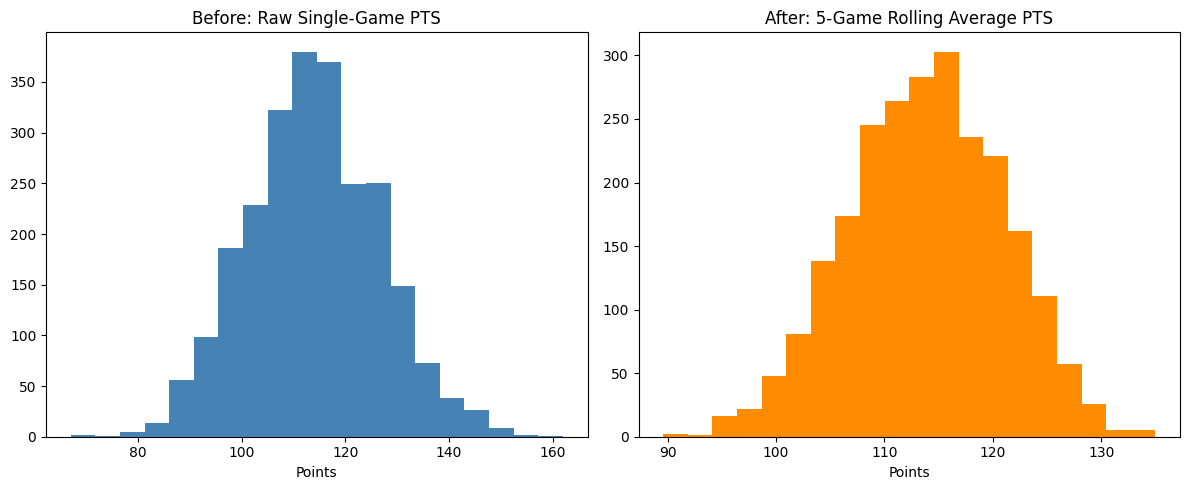

In [18]:
# Visual before/after: raw PTS distribution vs. rolling PTS_roll5 distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_2025['PTS'], bins=20, color='steelblue')
axes[0].set_title('Before: Raw Single-Game PTS')
axes[0].set_xlabel('Points')

axes[1].hist(df_model['PTS_roll5'], bins=20, color='darkorange')
axes[1].set_title('After: 5-Game Rolling Average PTS')
axes[1].set_xlabel('Points')

plt.tight_layout()
plt.show()

In [19]:
#part 5 - summary statistics
df_model.describe()

,gameid,date,PTS_roll5,PTS_roll10,FG%_roll5,FG%_roll10,3P%_roll5,3P%_roll10,REB_roll5,REB_roll10,...,TOV_roll10,STL_roll5,STL_roll10,BLK_roll5,BLK_roll10,ast_tov_roll5,ast_tov_roll10,is_home,rest_days,win
count,2.400000e+03,2400,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,...,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,2.240063e+07,2025-01-19 21:52:48,113.819729,113.790616,46.803326,46.755331,35.993692,35.969909,44.074104,44.088417,...,14.355650,8.205979,8.214439,4.896597,4.929619,2.042864,2.034397,0.498333,2.122500,0.500000
min,2.240000e+07,2024-10-26 00:00:00,89.600000,95.300000,37.360000,37.950000,19.500000,19.500000,33.000000,35.000000,...,9.000000,3.200000,3.500000,1.500000,1.500000,0.969683,1.026738,0.000000,1.000000,0.000000
25%,2.240033e+07,2024-12-05 00:00:00,109.150000,109.800000,44.800000,45.050000,33.460000,34.120000,41.600000,42.100000,...,13.100000,7.000000,7.300000,4.000000,4.200000,1.720951,1.758643,0.000000,2.000000,0.000000
50%,2.240063e+07,2025-01-20 00:00:00,114.000000,113.900000,46.800000,46.810000,36.060000,36.005000,44.000000,44.000000,...,14.300000,8.200000,8.100000,4.800000,4.800000,1.984498,2.013213,0.000000,2.000000,0.500000
75%,2.240093e+07,2025-03-06 00:00:00,119.000000,118.000000,48.800000,48.467500,38.545000,37.890000,46.400000,45.925000,...,15.500000,9.200000,9.000000,5.600000,5.500000,2.319536,2.272764,1.000000,2.000000,1.000000
max,2.240123e+07,2025-04-13 00:00:00,135.000000,133.500000,55.800000,54.900000,50.420000,44.630000,58.500000,58.500000,...,23.000000,14.400000,14.000000,10.000000,10.000000,4.875000,4.875000,1.000000,9.000000,1.000000
std,3.490163e+02,NaN,7.089717,6.112191,2.949655,2.514340,3.858540,3.017735,3.544053,2.906407,...,1.758585,1.672738,1.371001,1.275162,1.043472,0.446430,0.369223,0.500101,1.007679,0.500104


In [20]:
pd.set_option('display.max_columns', None)
df_model.describe()

,gameid,date,PTS_roll5,PTS_roll10,FG%_roll5,FG%_roll10,3P%_roll5,3P%_roll10,REB_roll5,REB_roll10,AST_roll5,AST_roll10,TOV_roll5,TOV_roll10,STL_roll5,STL_roll10,BLK_roll5,BLK_roll10,ast_tov_roll5,ast_tov_roll10,is_home,rest_days,win
count,2.400000e+03,2400,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,2.240063e+07,2025-01-19 21:52:48,113.819729,113.790616,46.803326,46.755331,35.993692,35.969909,44.074104,44.088417,26.529417,26.495446,14.317160,14.355650,8.205979,8.214439,4.896597,4.929619,2.042864,2.034397,0.498333,2.122500,0.500000
min,2.240000e+07,2024-10-26 00:00:00,89.600000,95.300000,37.360000,37.950000,19.500000,19.500000,33.000000,35.000000,17.250000,17.250000,7.600000,9.000000,3.200000,3.500000,1.500000,1.500000,0.969683,1.026738,0.000000,1.000000,0.000000
25%,2.240033e+07,2024-12-05 00:00:00,109.150000,109.800000,44.800000,45.050000,33.460000,34.120000,41.600000,42.100000,24.400000,24.600000,12.800000,13.100000,7.000000,7.300000,4.000000,4.200000,1.720951,1.758643,0.000000,2.000000,0.000000
50%,2.240063e+07,2025-01-20 00:00:00,114.000000,113.900000,46.800000,46.810000,36.060000,36.005000,44.000000,44.000000,26.400000,26.400000,14.200000,14.300000,8.200000,8.100000,4.800000,4.800000,1.984498,2.013213,0.000000,2.000000,0.500000
75%,2.240093e+07,2025-03-06 00:00:00,119.000000,118.000000,48.800000,48.467500,38.545000,37.890000,46.400000,45.925000,28.600000,28.400000,15.800000,15.500000,9.200000,9.000000,5.600000,5.500000,2.319536,2.272764,1.000000,2.000000,1.000000
max,2.240123e+07,2025-04-13 00:00:00,135.000000,133.500000,55.800000,54.900000,50.420000,44.630000,58.500000,58.500000,36.600000,36.500000,23.000000,23.000000,14.400000,14.000000,10.000000,10.000000,4.875000,4.875000,1.000000,9.000000,1.000000
std,3.490163e+02,NaN,7.089717,6.112191,2.949655,2.514340,3.858540,3.017735,3.544053,2.906407,3.028806,2.647053,2.105722,1.758585,1.672738,1.371001,1.275162,1.043472,0.446430,0.369223,0.500101,1.007679,0.500104


In [21]:
# Frequency tables for categorical columns
print(df_model['team'].value_counts())
print()
print(df_model['opponent'].value_counts())
print()
print(df_model['is_home'].value_counts())

team
ATL    80
BKN    80
BOS    80
CHA    80
CHI    80
CLE    80
DAL    80
DEN    80
DET    80
GSW    80
HOU    80
IND    80
LAC    80
LAL    80
MEM    80
MIA    80
MIL    80
MIN    80
NOP    80
NYK    80
OKC    80
ORL    80
PHI    80
PHX    80
POR    80
SAC    80
SAS    80
TOR    80
UTA    80
WAS    80
Name: count, dtype: int64

opponent
OKC    81
WAS    81
SAC    81
DAL    81
MIA    81
SAS    81
NYK    80
DET    80
GSW    80
POR    80
MIL    80
MEM    80
BOS    80
NOP    80
BKN    80
IND    80
PHI    80
DEN    80
TOR    80
MIN    80
LAC    80
UTA    80
ATL    80
ORL    80
CHI    79
CLE    79
CHA    79
LAL    79
HOU    79
PHX    79
Name: count, dtype: int64

is_home
0    1204
1    1196
Name: count, dtype: int64


In [22]:
# Check for outliers using the IQR method
Q1 = df_model[feature_cols].quantile(0.25)
Q3 = df_model[feature_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = {}
for col in feature_cols:
    outliers = df_model[(df_model[col] < lower_bound[col]) | (df_model[col] > upper_bound[col])]
    outlier_counts[col] = len(outliers)

pd.Series(outlier_counts).sort_values(ascending=False)

,0
rest_days,901
BLK_roll10,50
BLK_roll5,50
STL_roll10,45
3P%_roll10,40
STL_roll5,38
ast_tov_roll5,36
REB_roll10,34
3P%_roll5,31
REB_roll5,21


In [23]:
print(IQR["rest_days"])

0.0


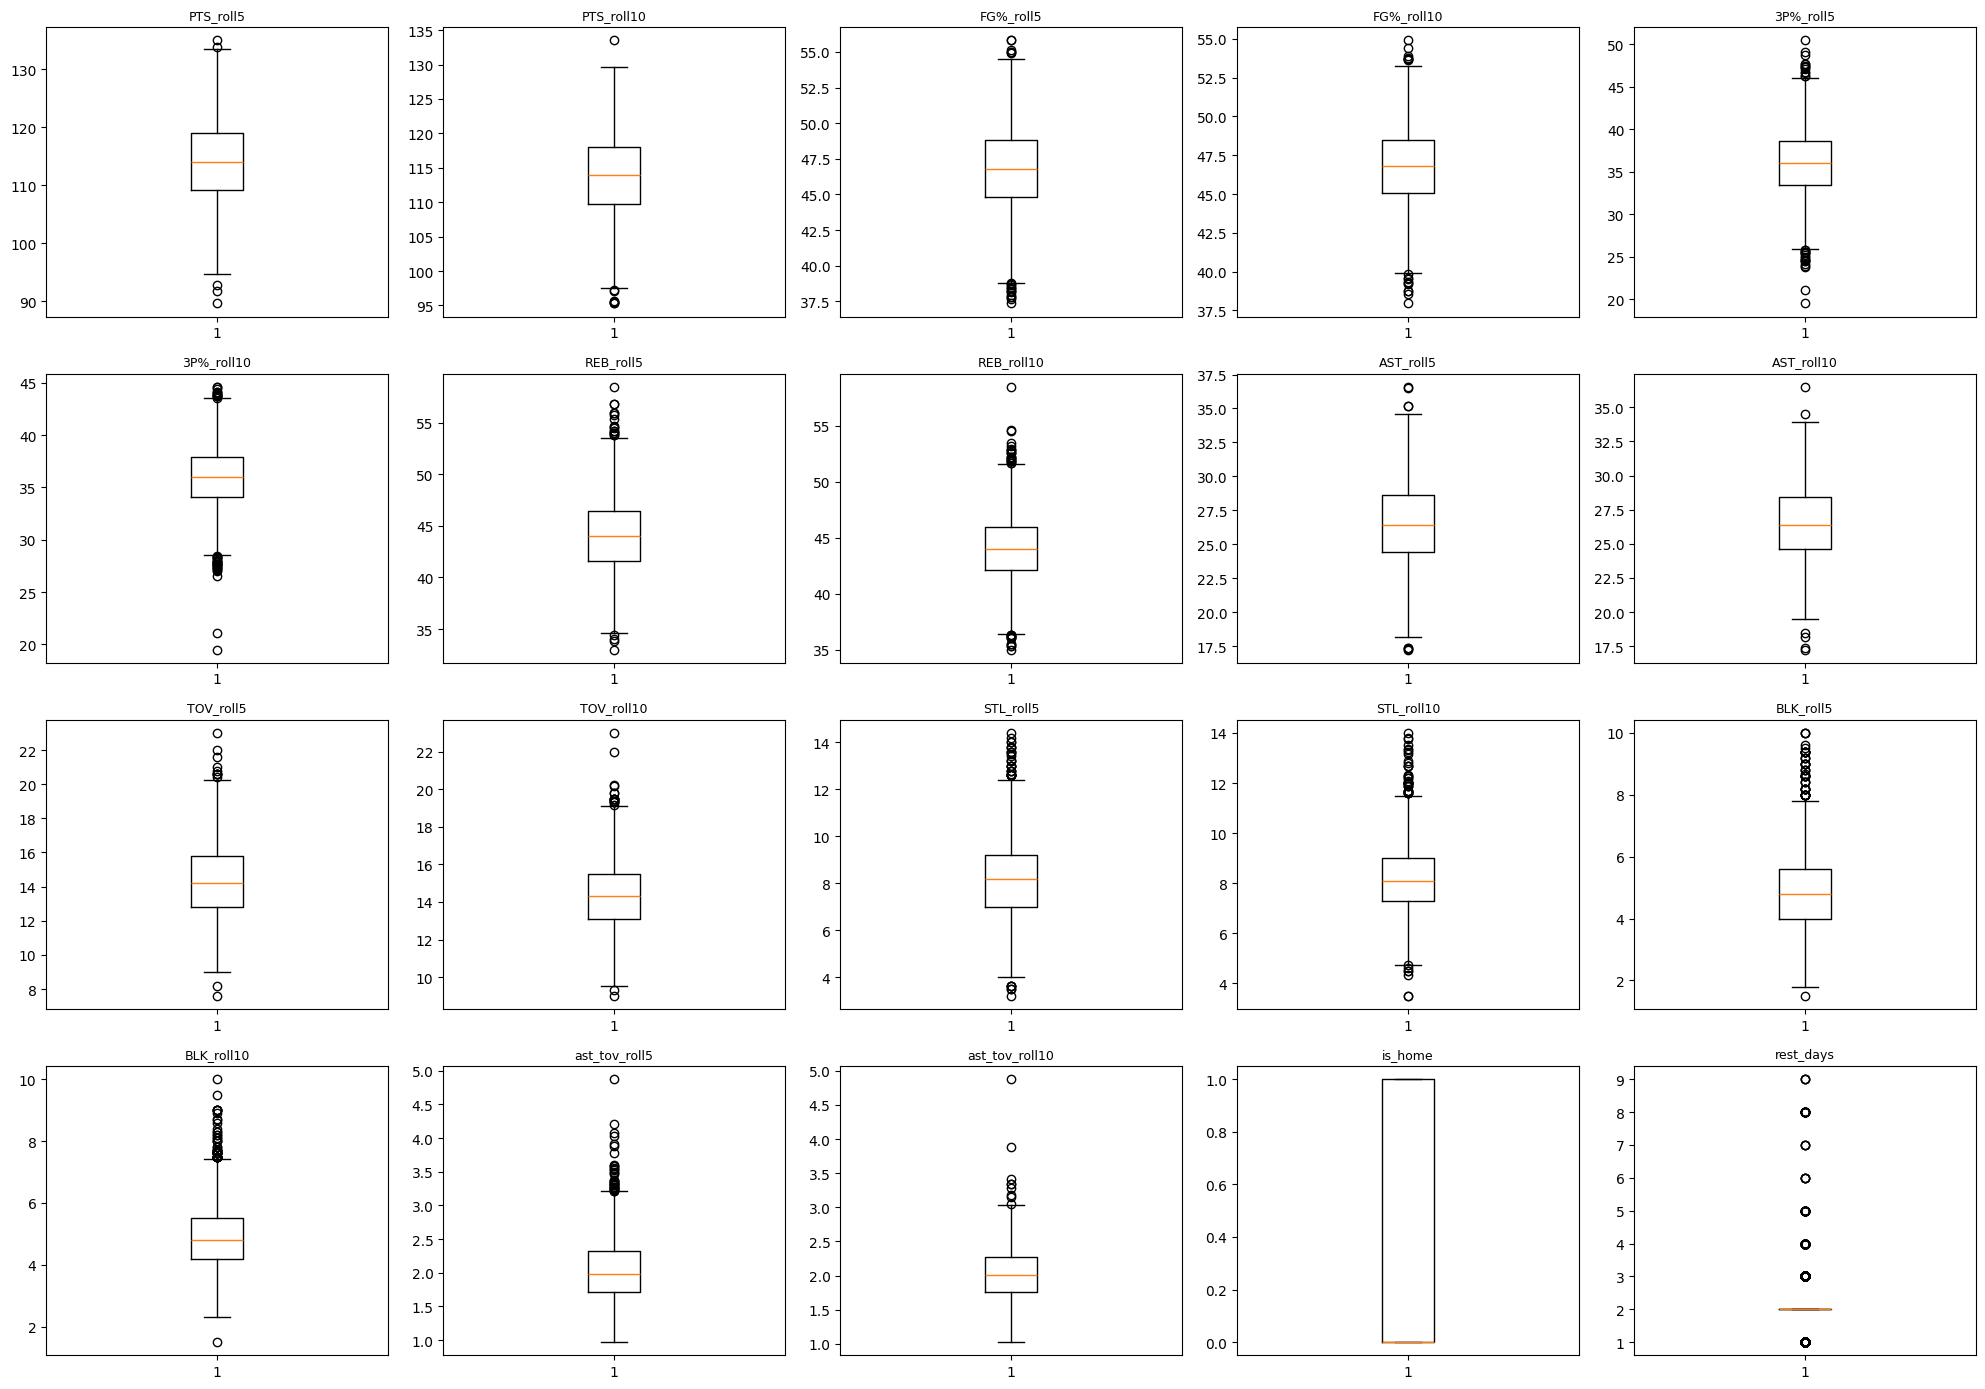

In [24]:
# Visualize with boxplots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df_model[col].dropna())
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

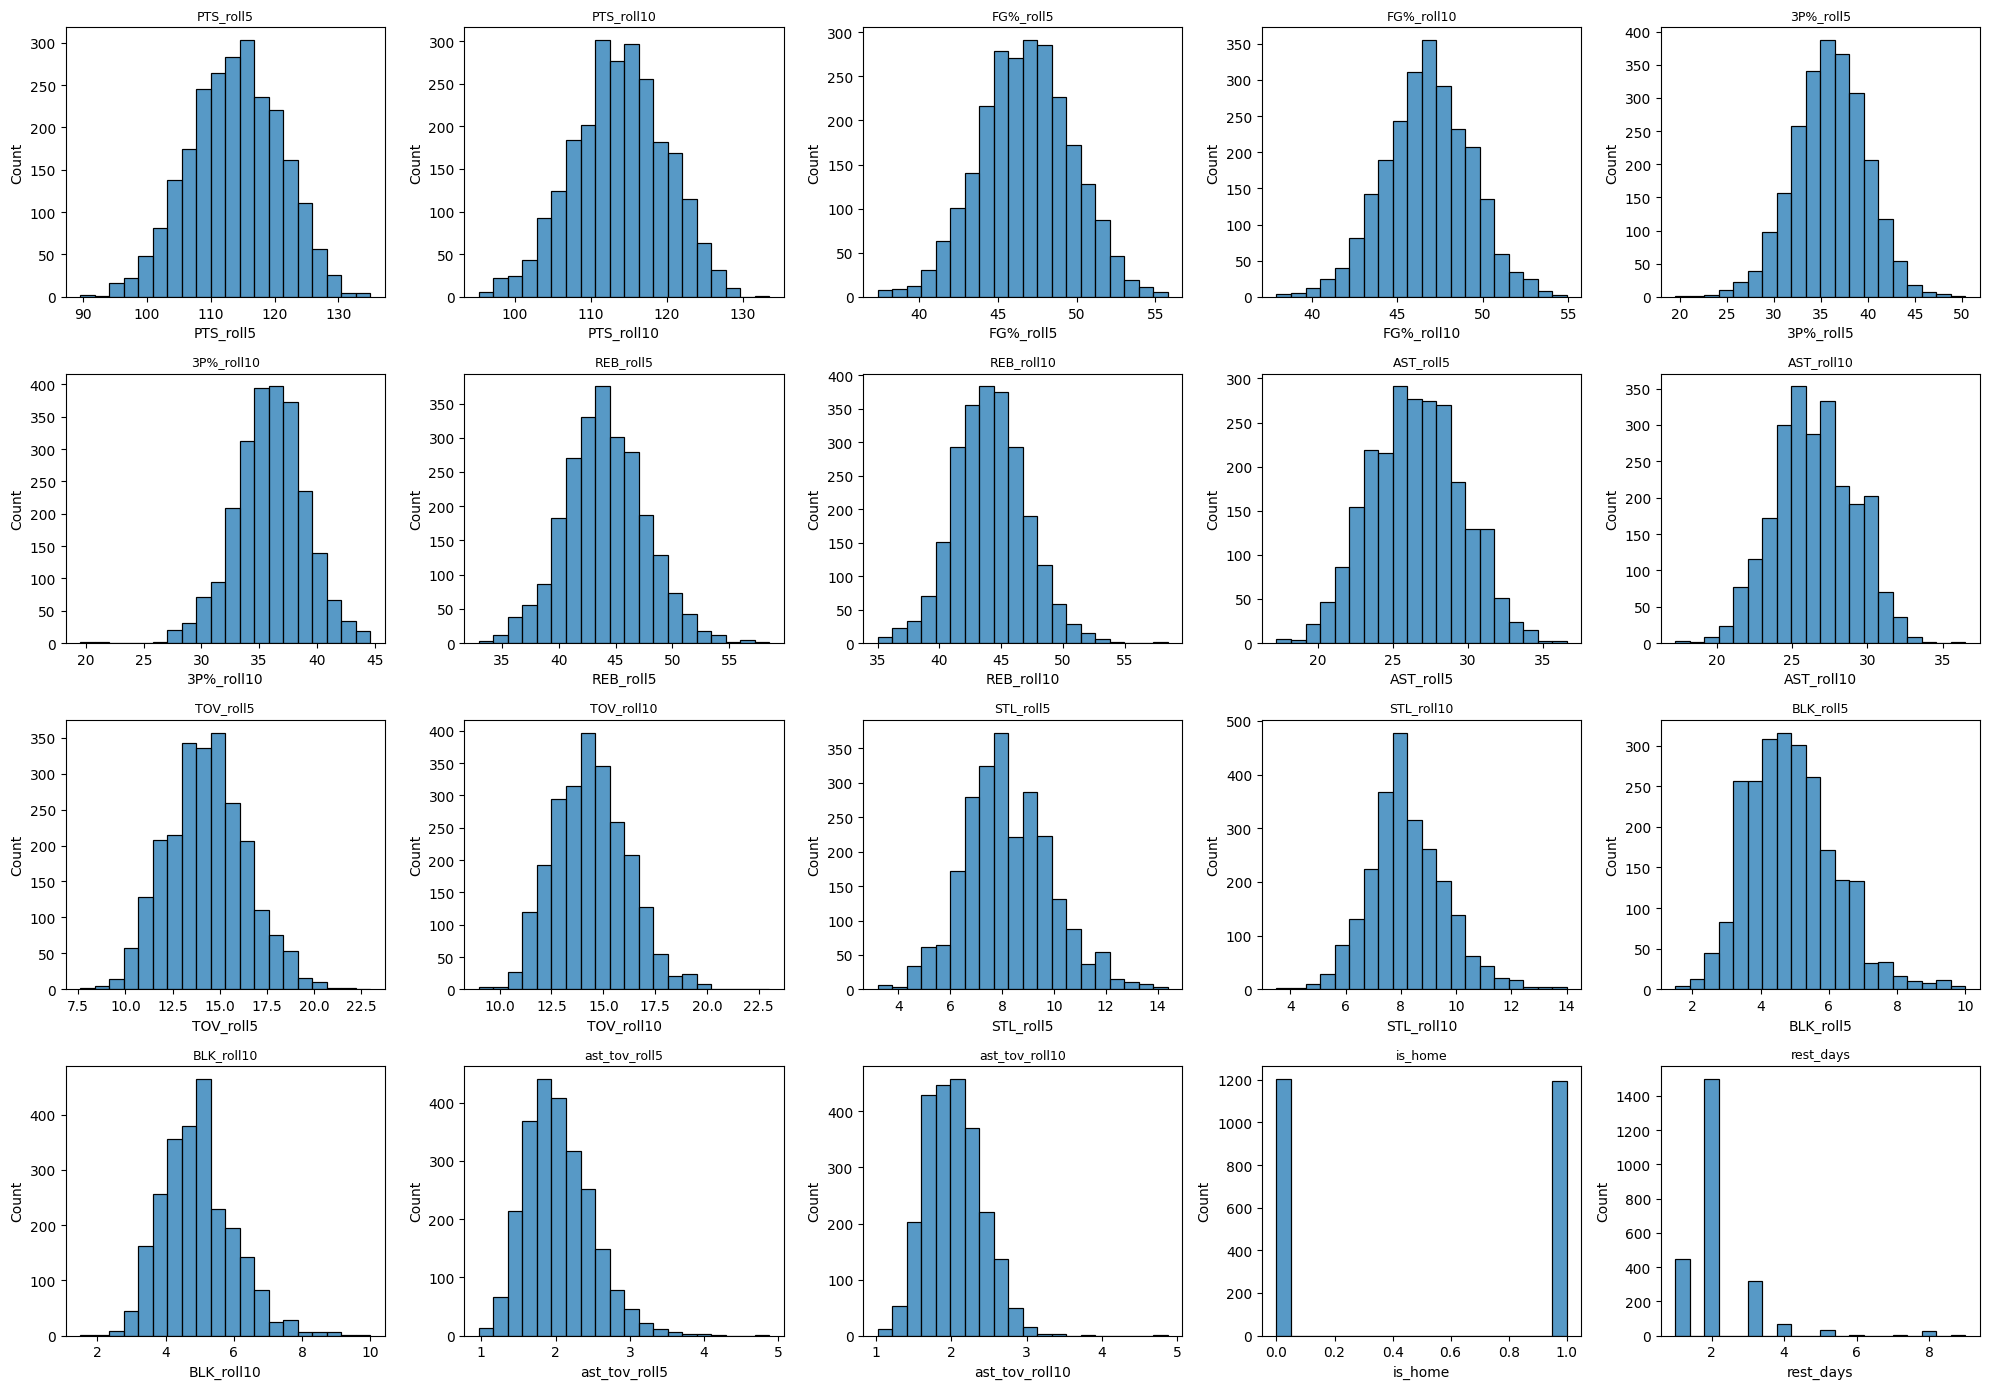

In [25]:
#part 6: visualizations

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df_model[col].dropna(), bins=20, ax=axes[i])
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

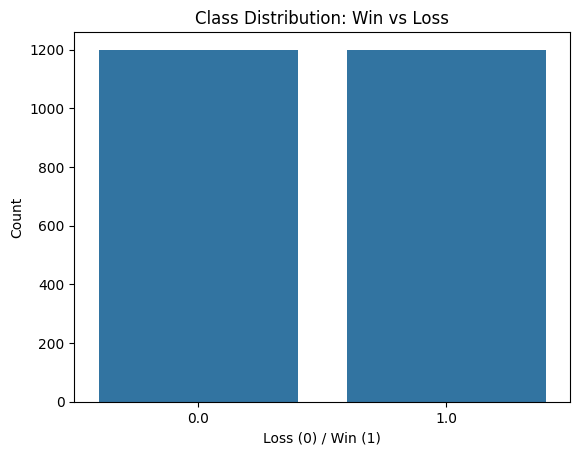

In [26]:
#bar chart of target variable
sns.countplot(x='win', data=df_model)
plt.title('Class Distribution: Win vs Loss')
plt.xlabel('Loss (0) / Win (1)')
plt.ylabel('Count')
plt.show()

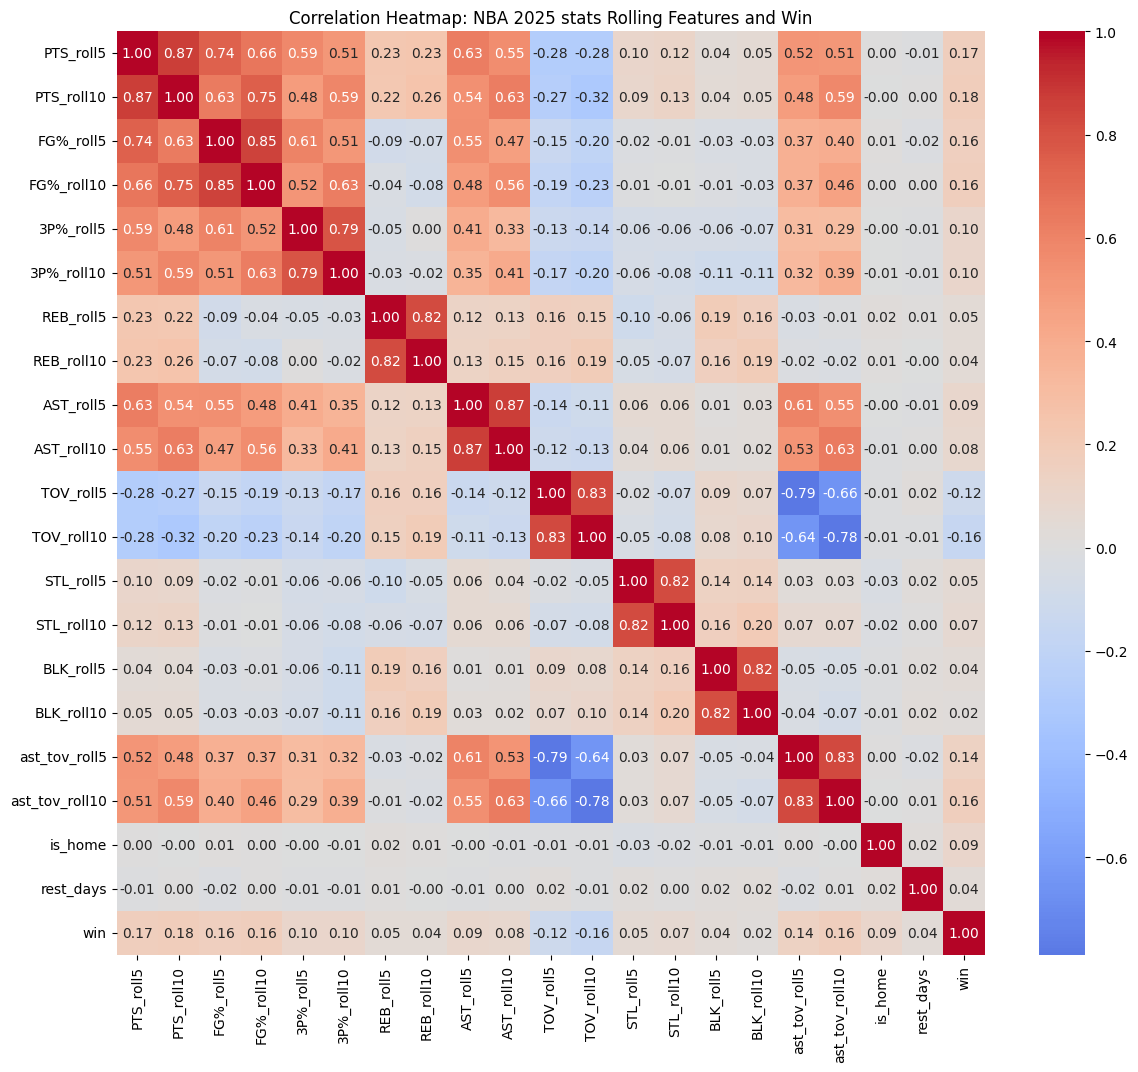

In [27]:
#correlation matrix heatmap
plt.figure(figsize=(14, 12))
corr_cols = feature_cols + ['win']
sns.heatmap(df_model[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: NBA 2025 stats Rolling Features and Win')
plt.show()

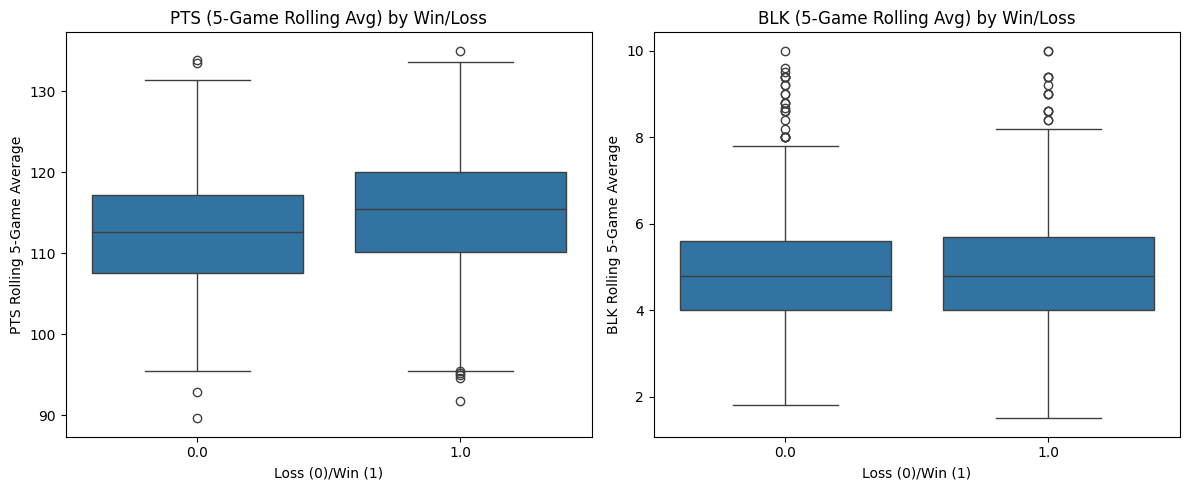

In [28]:
#boxplots comparing a feature across classes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='win', y='PTS_roll5', data=df_model, ax=axes[0])
axes[0].set_title('PTS (5-Game Rolling Avg) by Win/Loss')
axes[0].set_xlabel('Loss (0)/Win (1)')
axes[0].set_ylabel('PTS Rolling 5-Game Average')

sns.boxplot(x='win', y='BLK_roll5', data=df_model, ax=axes[1])
axes[1].set_title('BLK (5-Game Rolling Avg) by Win/Loss')
axes[1].set_xlabel('Loss (0)/Win (1)')
axes[1].set_ylabel('BLK Rolling 5-Game Average')

plt.tight_layout()
plt.show()

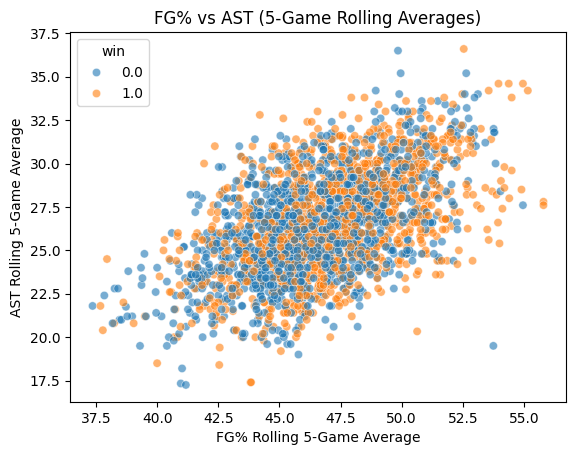

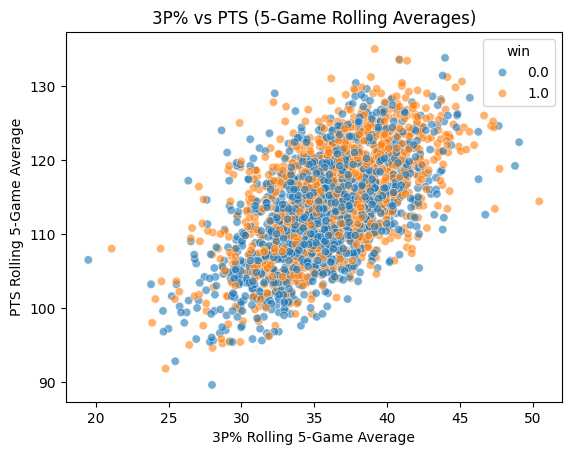

In [29]:
#Scatterplots for relationships between key variables
sns.scatterplot(x='FG%_roll5', y='AST_roll5', hue ='win', data=df_model, alpha=0.6)
plt.title('FG% vs AST (5-Game Rolling Averages)')
plt.xlabel('FG% Rolling 5-Game Average')
plt.ylabel('AST Rolling 5-Game Average')
plt.show()


sns.scatterplot(x='3P%_roll5', y='PTS_roll5', hue = 'win', data=df_model, alpha=0.6)
plt.title('3P% vs PTS (5-Game Rolling Averages)')
plt.xlabel('3P% Rolling 5-Game Average')
plt.ylabel('PTS Rolling 5-Game Average')
plt.show()

# Project Milestone 3


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score,confusion_matrix, precision_score, recall_score, f1_score, classification_report
import numpy as np
import pandas as pd

In [31]:
stats = ['PTS', 'FG%', '3P%', 'REB', 'AST', 'TOV', 'STL', 'BLK']
window_sizes = [5, 10, 15, 20, 25]

for w in window_sizes:
    for s in stats:
        shifted = df_2025.groupby('team')[s].shift(1)
        df_2025[f'{s}_roll{w}'] = shifted.groupby(df_2025['team']).rolling(w, min_periods=2).mean().reset_index(drop=True)

In [32]:
feature_cols_all = [f'{s}_roll{w}' for s in stats for w in window_sizes] + ['is_home', 'rest_days']
id_cols = ['gameid', 'date', 'team']

df_model2 = df_2025[id_cols + feature_cols_all + ['win']].dropna(subset=feature_cols_all).reset_index(drop=True)
df_model2 = df_model2.sort_values('date').reset_index(drop=True)

print(df_model2.shape)
print(df_model2.columns.tolist())

(2400, 46)
['gameid', 'date', 'team', 'PTS_roll5', 'PTS_roll10', 'PTS_roll15', 'PTS_roll20', 'PTS_roll25', 'FG%_roll5', 'FG%_roll10', 'FG%_roll15', 'FG%_roll20', 'FG%_roll25', '3P%_roll5', '3P%_roll10', '3P%_roll15', '3P%_roll20', '3P%_roll25', 'REB_roll5', 'REB_roll10', 'REB_roll15', 'REB_roll20', 'REB_roll25', 'AST_roll5', 'AST_roll10', 'AST_roll15', 'AST_roll20', 'AST_roll25', 'TOV_roll5', 'TOV_roll10', 'TOV_roll15', 'TOV_roll20', 'TOV_roll25', 'STL_roll5', 'STL_roll10', 'STL_roll15', 'STL_roll20', 'STL_roll25', 'BLK_roll5', 'BLK_roll10', 'BLK_roll15', 'BLK_roll20', 'BLK_roll25', 'is_home', 'rest_days', 'win']


Before building my actual baseline model, I treated the rolling window length itself as a parameter to test, rather than picking a fixed number upfront. I used an LLM (Claude) to help aid me in  training a simple, untuned Logistic Regression model separately on each of the rolling averages including the new ones I created, holding everything else identical (same train/test split, same model settings) so window size was the only variable changing between tests. I compared each version on accuracy and ROC-AUC, then selected the best-performing window size for my final feature set going forward.

In [33]:
split_idx2 = int(len(df_model2) * 0.8)
train2, test2 = df_model2.iloc[:split_idx2], df_model2.iloc[split_idx2:]

for w in window_sizes:
    feats = [c for c in feature_cols_all if f'roll{w}' in c] + ['is_home', 'rest_days']
    feats = list(dict.fromkeys(feats))

    X_tr, X_te = train2[feats], test2[feats]
    y_tr, y_te = train2['win'], test2['win']

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    m = LogisticRegression(random_state=42, max_iter=1000)
    m.fit(X_tr_s, y_tr)
    pred = m.predict(X_te_s)
    proba = m.predict_proba(X_te_s)[:, 1]

    print(f"{w}-game window: accuracy={accuracy_score(y_te, pred):.4f}, ROC-AUC={roc_auc_score(y_te, proba):.4f}")

5-game window: accuracy=0.6000, ROC-AUC=0.6488
10-game window: accuracy=0.6042, ROC-AUC=0.6565
15-game window: accuracy=0.6146, ROC-AUC=0.6511
20-game window: accuracy=0.6208, ROC-AUC=0.6637
25-game window: accuracy=0.5958, ROC-AUC=0.6561


Logistic Regression model

In [51]:
#Build final feature set: 20-game window
feature_cols = [f'{s}_roll20' for s in stats] + ['is_home', 'rest_days']
id_cols = ['gameid', 'date', 'team','opponent']

df_model_final = df_2025[id_cols + feature_cols + ['win']].dropna(subset=feature_cols).reset_index(drop=True)
df_model_final = df_model_final.sort_values('date').reset_index(drop=True)

print(df_model_final.shape)

(2400, 15)


In [52]:
# Select Features and Target
X = df_model_final[feature_cols]
y = df_model_final['win']

# Chronological Train/Test Split
split_idx = int(len(df_model_final) * 0.8)
X_train = df_model_final.iloc[:split_idx][feature_cols]
X_test = df_model_final.iloc[split_idx:][feature_cols]
y_train = df_model_final.iloc[:split_idx]['win']
y_test = df_model_final.iloc[split_idx:]['win']

print(X_train.shape, X_test.shape)

(1920, 10) (480, 10)


In [53]:
#Check Data imbalance before going into training
print("Full dataset class balance:")
print(df_model_final['win'].value_counts(normalize=True))

print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True))

print("\nTest set class balance:")
print(y_test.value_counts(normalize=True))

Full dataset class balance:
win
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

Training set class balance:
win
0.0    0.501042
1.0    0.498958
Name: proportion, dtype: float64

Test set class balance:
win
1.0    0.504167
0.0    0.495833
Name: proportion, dtype: float64


In [54]:
# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [43]:
# Generate Predictions and Evaluate
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.6208333333333333
ROC-AUC: 0.6637440100006946
              precision    recall  f1-score   support

         0.0       0.66      0.48      0.56       238
         1.0       0.60      0.76      0.67       242

    accuracy                           0.62       480
   macro avg       0.63      0.62      0.61       480
weighted avg       0.63      0.62      0.61       480



In [39]:
#Coefficients
coef_df = pd.DataFrame({"Feature": feature_cols, "Coefficient": log_reg.coef_[0]})
print(coef_df.sort_values(by="Coefficient", ascending=False).to_string())

      Feature  Coefficient
1  FG%_roll20     0.265080
8     is_home     0.220826
6  STL_roll20     0.129983
3  REB_roll20     0.124050
0  PTS_roll20     0.091951
9   rest_days     0.064309
7  BLK_roll20    -0.002501
2  3P%_roll20    -0.003568
4  AST_roll20    -0.072711
5  TOV_roll20    -0.283215


-used k=5 with TimeSeriesSplit instead of standard randomly shuffled k-fold cross-validation to prevent future games in training data

-chose five folds because the training set contains 1,920 games. Using five folds provides multiple chronological validation periods while maintaining reasonably sized validation sets

In [47]:
# k-fold cross-validation using TimeSeriesSplit (k=5)
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
fold_acc = []

for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    sc = StandardScaler()
    X_tr_scaled = sc.fit_transform(X_tr)
    X_val_scaled = sc.transform(X_val)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_tr_scaled, y_tr)

    acc = accuracy_score(y_val, model.predict(X_val_scaled))
    fold_acc.append(acc)
    print(f"Fold {i+1}: train={len(tr_idx)} games, val={len(val_idx)} games, accuracy={acc:.4f}")

fold_acc = np.array(fold_acc)
print(f"\nMean CV accuracy: {fold_acc.mean():.4f}")
print(f"Variance: {fold_acc.var():.6f}")
print(f"Std Dev: {fold_acc.std():.4f}")

Fold 1: train=320 games, val=320 games, accuracy=0.5875
Fold 2: train=640 games, val=320 games, accuracy=0.5969
Fold 3: train=960 games, val=320 games, accuracy=0.5938
Fold 4: train=1280 games, val=320 games, accuracy=0.5813
Fold 5: train=1600 games, val=320 games, accuracy=0.5875

Mean CV accuracy: 0.5894
Variance: 0.000030
Std Dev: 0.0054


Parameter Tuning



*   C parameter controls the strength of regularization. Smaller values apply stronger regularization, while larger values apply weaker regularization

*   penalty (L1,L2) parameter determines the type of regularization. L1 can shrink coefficients to zero and L2 can shrink them gradually without eliminating them




In [70]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='accuracy'
)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
tuned_pred = best_model.predict(X_test_scaled)
tuned_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("Best parameters found by grid search:", grid.best_params_)

comparison = pd.DataFrame({
    "Model": ["Untuned (default: C=1.0, l2-equivalent)", "Tuned (best from grid search)"],
    "Accuracy": [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, tuned_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, tuned_proba)]
})
comparison

Best parameters found by grid search: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


,Model,Accuracy,ROC-AUC
0,"Untuned (default: C=1.0, l2-equivalent)",0.620833,0.663744
1,Tuned (best from grid search),0.610417,0.661747


Evaluation Metrics



*  ROC-AUC will be my most important for comparing against other models




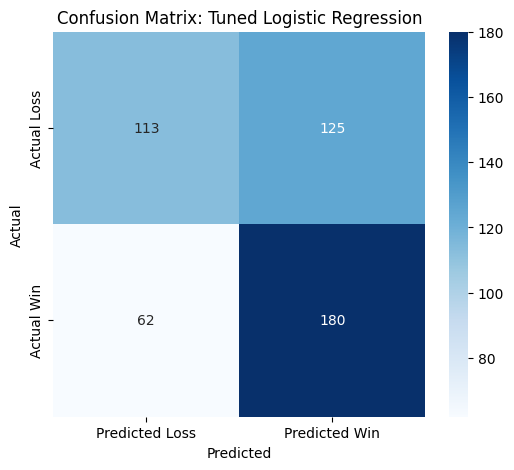

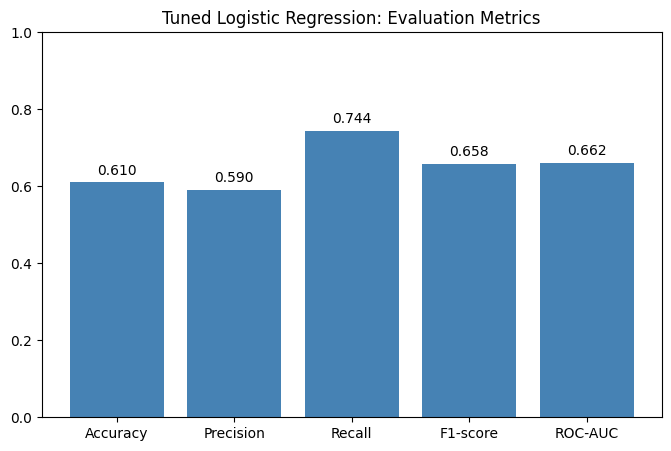

In [67]:
cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'])
plt.title('Confusion Matrix: Tuned Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

metrics_dict = {
    'Accuracy': accuracy_score(y_test, tuned_pred),
    'Precision': precision_score(y_test, tuned_pred),
    'Recall': recall_score(y_test, tuned_pred),
    'F1-score': f1_score(y_test, tuned_pred),
    'ROC-AUC': roc_auc_score(y_test, tuned_proba)
}

plt.figure(figsize=(8, 5))
plt.bar(metrics_dict.keys(), metrics_dict.values(), color='steelblue')
plt.ylim(0, 1)
for i, (k, v) in enumerate(metrics_dict.items()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.title('Tuned Logistic Regression: Evaluation Metrics')
plt.show()

Naive baseline

In [49]:
#persistence baseline
df_2025['prev_win'] = df_2025.groupby('team')['win'].shift(1)
df_persist = df_2025[['gameid', 'date', 'team', 'win', 'prev_win']].dropna(subset=['prev_win']).reset_index(drop=True)
df_persist = df_persist.sort_values('date').reset_index(drop=True)

sp = int(len(df_persist) * 0.8)
persistence_acc = accuracy_score(df_persist.iloc[sp:]['win'], df_persist.iloc[sp:]['prev_win'])

print(f"persistence baseline -> accuracy: {persistence_acc:.4f}")
print(f"tuned logistic regression -> accuracy: {accuracy_score(y_test, tuned_pred):.4f}")

persistence baseline -> accuracy: 0.5864
tuned logistic regression -> accuracy: 0.6104


In [64]:
#error analysis
test_df = df_model_final.iloc[split_idx:].copy().reset_index(drop=True)
test_df['pred'] = tuned_pred
test_df['actual'] = y_test.values
test_df['FG%_roll20'] = X_test['FG%_roll20'].values

misclassified = test_df[test_df['pred'] != test_df['actual']]
print("Total misclassified:", len(misclassified), "of", len(test_df))

league_avg_fg = X_train['FG%_roll20'].mean()
print("League average FG%_roll20:", league_avg_fg)

misclassified[['date', 'team', 'opponent', 'actual', 'pred', 'FG%_roll20']].head(8)

Total misclassified: 187 of 480
League average FG%_roll20: 46.5544556387182


,date,team,opponent,actual,pred,FG%_roll20
0,2025-03-14,PHI,IND,0.0,1.0,46.300
3,2025-03-14,CHA,SAS,1.0,0.0,41.610
4,2025-03-14,TOR,UTA,1.0,0.0,44.475
12,2025-03-15,IND,MIL,0.0,1.0,49.010
13,2025-03-15,NYK,GSW,0.0,1.0,47.820
18,2025-03-15,DET,OKC,0.0,1.0,49.560
20,2025-03-15,DEN,WAS,0.0,1.0,51.595
27,2025-03-15,WAS,DEN,1.0,0.0,44.150


Learning curve:

Training accuracy fluctuates between roughly 0.61 and 0.66 as training set size increases, while validation accuracy rises steadily from about 0.52 to 0.59. At the smallest training size, there's a real gap of about 0.12 between the two curves, but this gap consistently narrows as more training data is added. Since the gap shrinks rather than staying the same or widening with more data, this isn't evidence of overfitting. Both curves also sit well above the 0.5 chance level rather than performing poorly together, so there's no evidence of underfitting either.

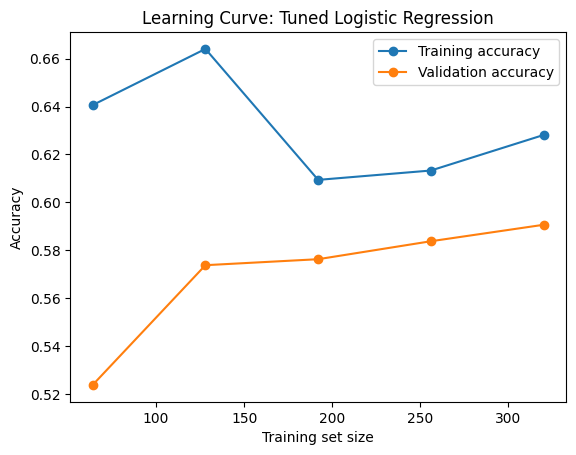

In [66]:
# Learning curves
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(C=best_model.C, penalty=best_model.penalty, solver='liblinear', random_state=42, max_iter=1000),
    X_train_scaled, y_train,
    cv=TimeSeriesSplit(n_splits=5),
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring='accuracy'
)

plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training accuracy')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation accuracy')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve: Tuned Logistic Regression')
plt.legend()
plt.show()

In [69]:
# Training and testing time
import time

t0 = time.time()
grid.fit(X_train_scaled, y_train)
train_time = time.time() - t0

t0 = time.time()
best_model.predict(X_test_scaled)
test_time = time.time() - t0

print(f"Training time (grid search): {train_time:.4f} seconds")
print(f"Prediction time (test set): {test_time:.6f} seconds")

Training time (grid search): 0.3088 seconds
Prediction time (test set): 0.000698 seconds


All results in this project used random_state=42 consistently across model initialization and grid search, ensuring the exact same results if this notebook is re-run. The train/test split itself required no random seed, since it was chronological (based on date order) rather than randomized. Library versions used: scikit-learn 1.8.0, numpy 2.4.4, pandas 3.0.2, Python 3.12.3.

In [ ]:
conn.close()

In [ ]:
from google.colab import files
files.download('capstone.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>